In [1]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score



warnings.filterwarnings('ignore')


In [2]:
print(sys.version)

3.12.5 (v3.12.5:ff3bc82f7c9, Aug  7 2024, 05:32:06) [Clang 13.0.0 (clang-1300.0.29.30)]


In [3]:
df = pd.read_csv("D600_Task_2_Dataset_1_Housing_Information.csv")
df['IsLuxury'] = df['IsLuxury'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ID                    7000 non-null   int64   
 1   Price                 7000 non-null   float64 
 2   SquareFootage         7000 non-null   float64 
 3   NumBathrooms          7000 non-null   float64 
 4   NumBedrooms           7000 non-null   int64   
 5   BackyardSpace         7000 non-null   float64 
 6   CrimeRate             7000 non-null   float64 
 7   SchoolRating          7000 non-null   float64 
 8   AgeOfHome             7000 non-null   float64 
 9   DistanceToCityCenter  7000 non-null   float64 
 10  EmploymentRate        7000 non-null   float64 
 11  PropertyTaxRate       7000 non-null   float64 
 12  RenovationQuality     7000 non-null   float64 
 13  LocalAmenities        7000 non-null   float64 
 14  TransportAccess       7000 non-null   float64 
 15  Fire

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop(columns=['ID'], inplace=True)

In [6]:
df.head()

,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,97.29,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,93.22,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,96.60,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,91.45,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,86.50,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0


# Describe Variables

Dependent Variable

In [7]:
df.IsLuxury.value_counts()

IsLuxury
1    3528
0    3472
Name: count, dtype: int64

Indepdent Variables

In [8]:
df_ind = df.drop(columns=['IsLuxury'])

In [9]:
print(df_ind.mode().iloc[0])

Price                       85000.0
SquareFootage                 550.0
NumBathrooms                    1.0
NumBedrooms                     3.0
BackyardSpace                300.08
CrimeRate                     34.01
SchoolRating                   10.0
AgeOfHome                     18.18
DistanceToCityCenter           8.29
EmploymentRate                 99.9
PropertyTaxRate                1.43
RenovationQuality              10.0
LocalAmenities                 10.0
TransportAccess                10.0
Fireplace                        No
HouseColor                    White
Garage                           No
Floors                          1.0
Windows                        14.0
PreviousSalePrice      -8356.902464
Name: 0, dtype: object


In [10]:
df_num = df_ind.select_dtypes('number')

In [11]:
df_num.describe()

,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,Floors,Windows,PreviousSalePrice
count,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.00000,7000.000000,7.000000e+03
mean,3.072820e+05,1048.947459,2.131397,3.008571,511.507029,31.226194,6.942923,46.797046,17.475337,93.711349,1.500437,5.003357,5.934579,5.983860,1.16300,16.248857,2.845094e+05
std,1.501734e+05,426.010482,0.952561,1.021940,279.926549,18.025327,1.888148,31.779701,12.024985,4.505359,0.498591,1.970428,2.657930,1.953974,0.37209,8.926479,1.857340e+05
min,8.500000e+04,550.000000,1.000000,1.000000,0.390000,0.030000,0.220000,0.010000,0.000000,72.050000,0.010000,0.010000,0.000000,0.010000,1.00000,-6.000000,-8.356902e+03
25%,1.921075e+05,660.815000,1.290539,2.000000,300.995000,17.390000,5.650000,20.755000,7.827500,90.620000,1.160000,3.660000,4.000000,4.680000,1.00000,11.000000,1.420140e+05
50%,2.793230e+05,996.320000,1.997774,3.000000,495.965000,30.385000,7.010000,42.620000,15.625000,94.010000,1.490000,5.020000,6.040000,6.000000,1.00000,15.000000,2.621831e+05
75%,3.918781e+05,1342.292500,2.763997,4.000000,704.012500,43.670000,8.360000,67.232500,25.222500,97.410000,1.840000,6.350000,8.050000,7.350000,1.00000,20.000000,3.961212e+05
max,1.046676e+06,2874.700000,5.807239,7.000000,1631.360000,99.730000,10.000000,178.680000,65.200000,99.900000,3.360000,10.000000,10.000000,10.000000,3.00000,63.000000,1.296607e+06


In [12]:
df_cat = df_ind.select_dtypes(exclude='number')

In [13]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Fireplace   7000 non-null   object
 1   HouseColor  7000 non-null   object
 2   Garage      7000 non-null   object
dtypes: object(3)
memory usage: 164.2+ KB


In [14]:
df_cat.Fireplace.value_counts()

Fireplace
No     5172
Yes    1828
Name: count, dtype: int64

In [15]:
df_cat.HouseColor.value_counts()

HouseColor
White     1446
Yellow    1423
Blue      1409
Green     1375
Red       1347
Name: count, dtype: int64

In [16]:
df_cat.Garage.value_counts()

Garage
No     4488
Yes    2512
Name: count, dtype: int64

# Univariate Graph

Dependent Variable

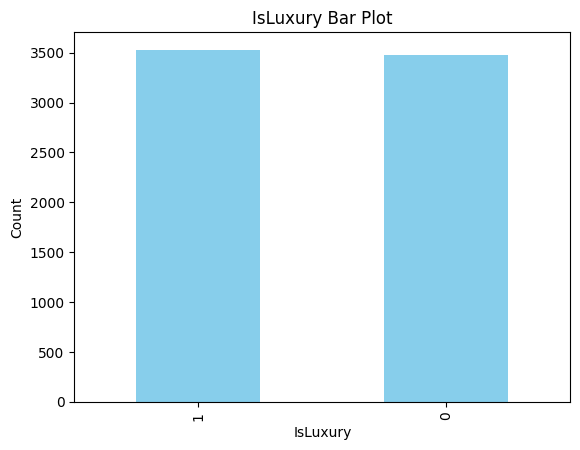

In [17]:
value_counts = df['IsLuxury'].value_counts()

value_counts.plot(kind='bar', color='skyblue')


# Add title and labels
plt.title("IsLuxury Bar Plot")
plt.xlabel("IsLuxury")
plt.ylabel("Count")

# Show the plot
plt.show()

Categorical Independent Variables

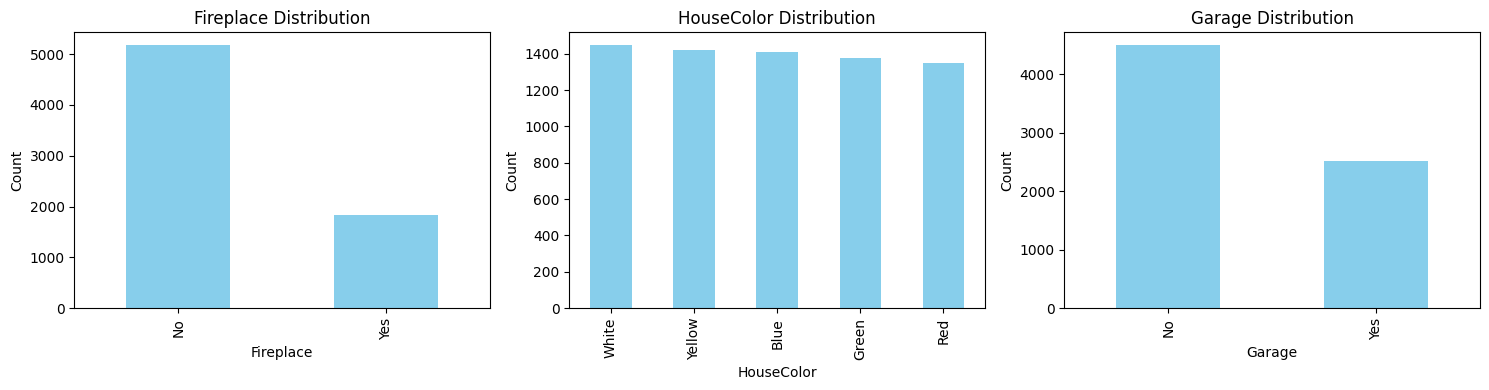

In [18]:
import matplotlib.pyplot as plt

cat_cols = df_cat.columns.tolist()  

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'SquareFootage'}>,
        <Axes: title={'center': 'NumBathrooms'}>,
        <Axes: title={'center': 'NumBedrooms'}>],
       [<Axes: title={'center': 'BackyardSpace'}>,
        <Axes: title={'center': 'CrimeRate'}>,
        <Axes: title={'center': 'SchoolRating'}>,
        <Axes: title={'center': 'AgeOfHome'}>],
       [<Axes: title={'center': 'DistanceToCityCenter'}>,
        <Axes: title={'center': 'EmploymentRate'}>,
        <Axes: title={'center': 'PropertyTaxRate'}>,
        <Axes: title={'center': 'RenovationQuality'}>],
       [<Axes: title={'center': 'LocalAmenities'}>,
        <Axes: title={'center': 'TransportAccess'}>,
        <Axes: title={'center': 'Floors'}>,
        <Axes: title={'center': 'Windows'}>],
       [<Axes: title={'center': 'PreviousSalePrice'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

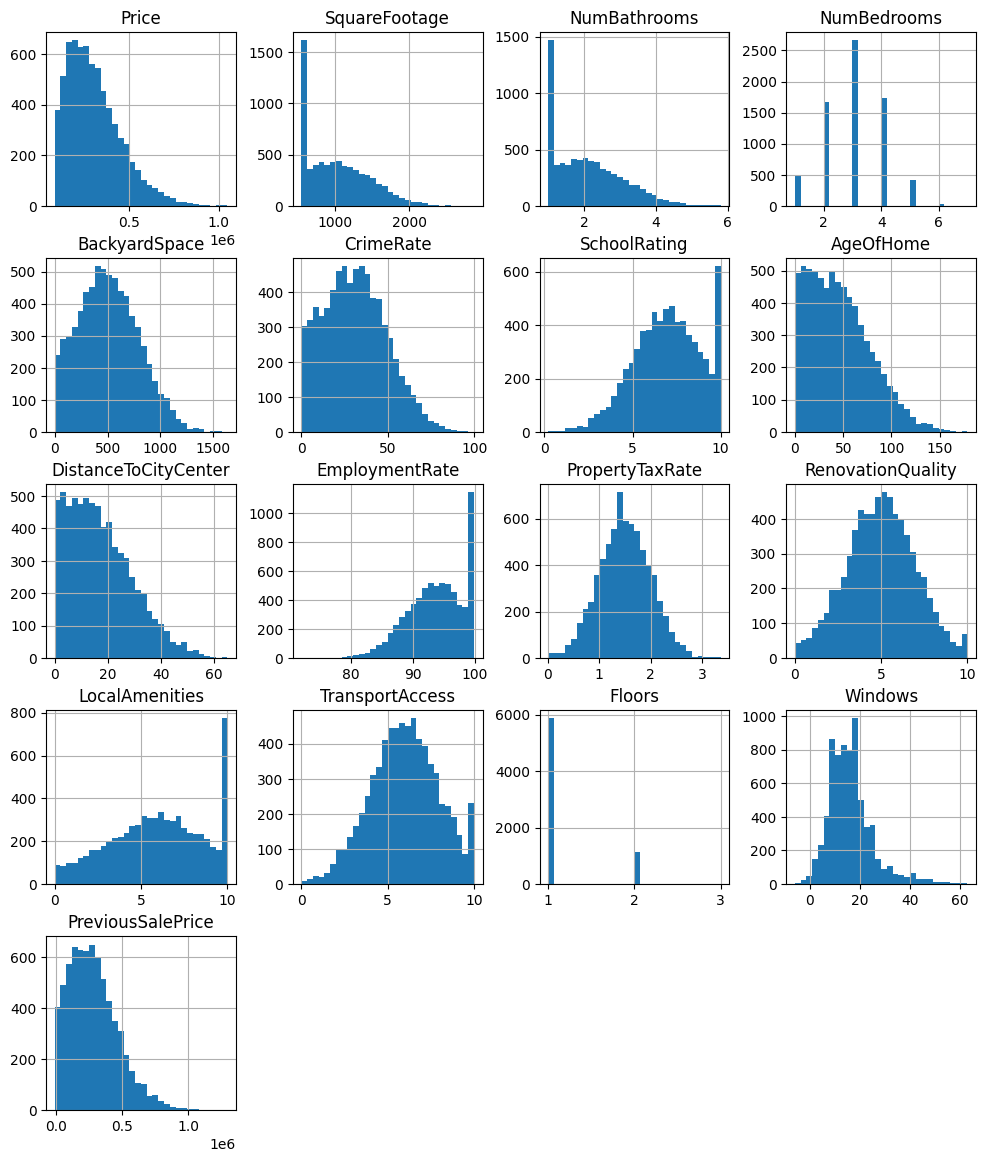

In [19]:
df.hist(figsize=(12,14), bins=30)

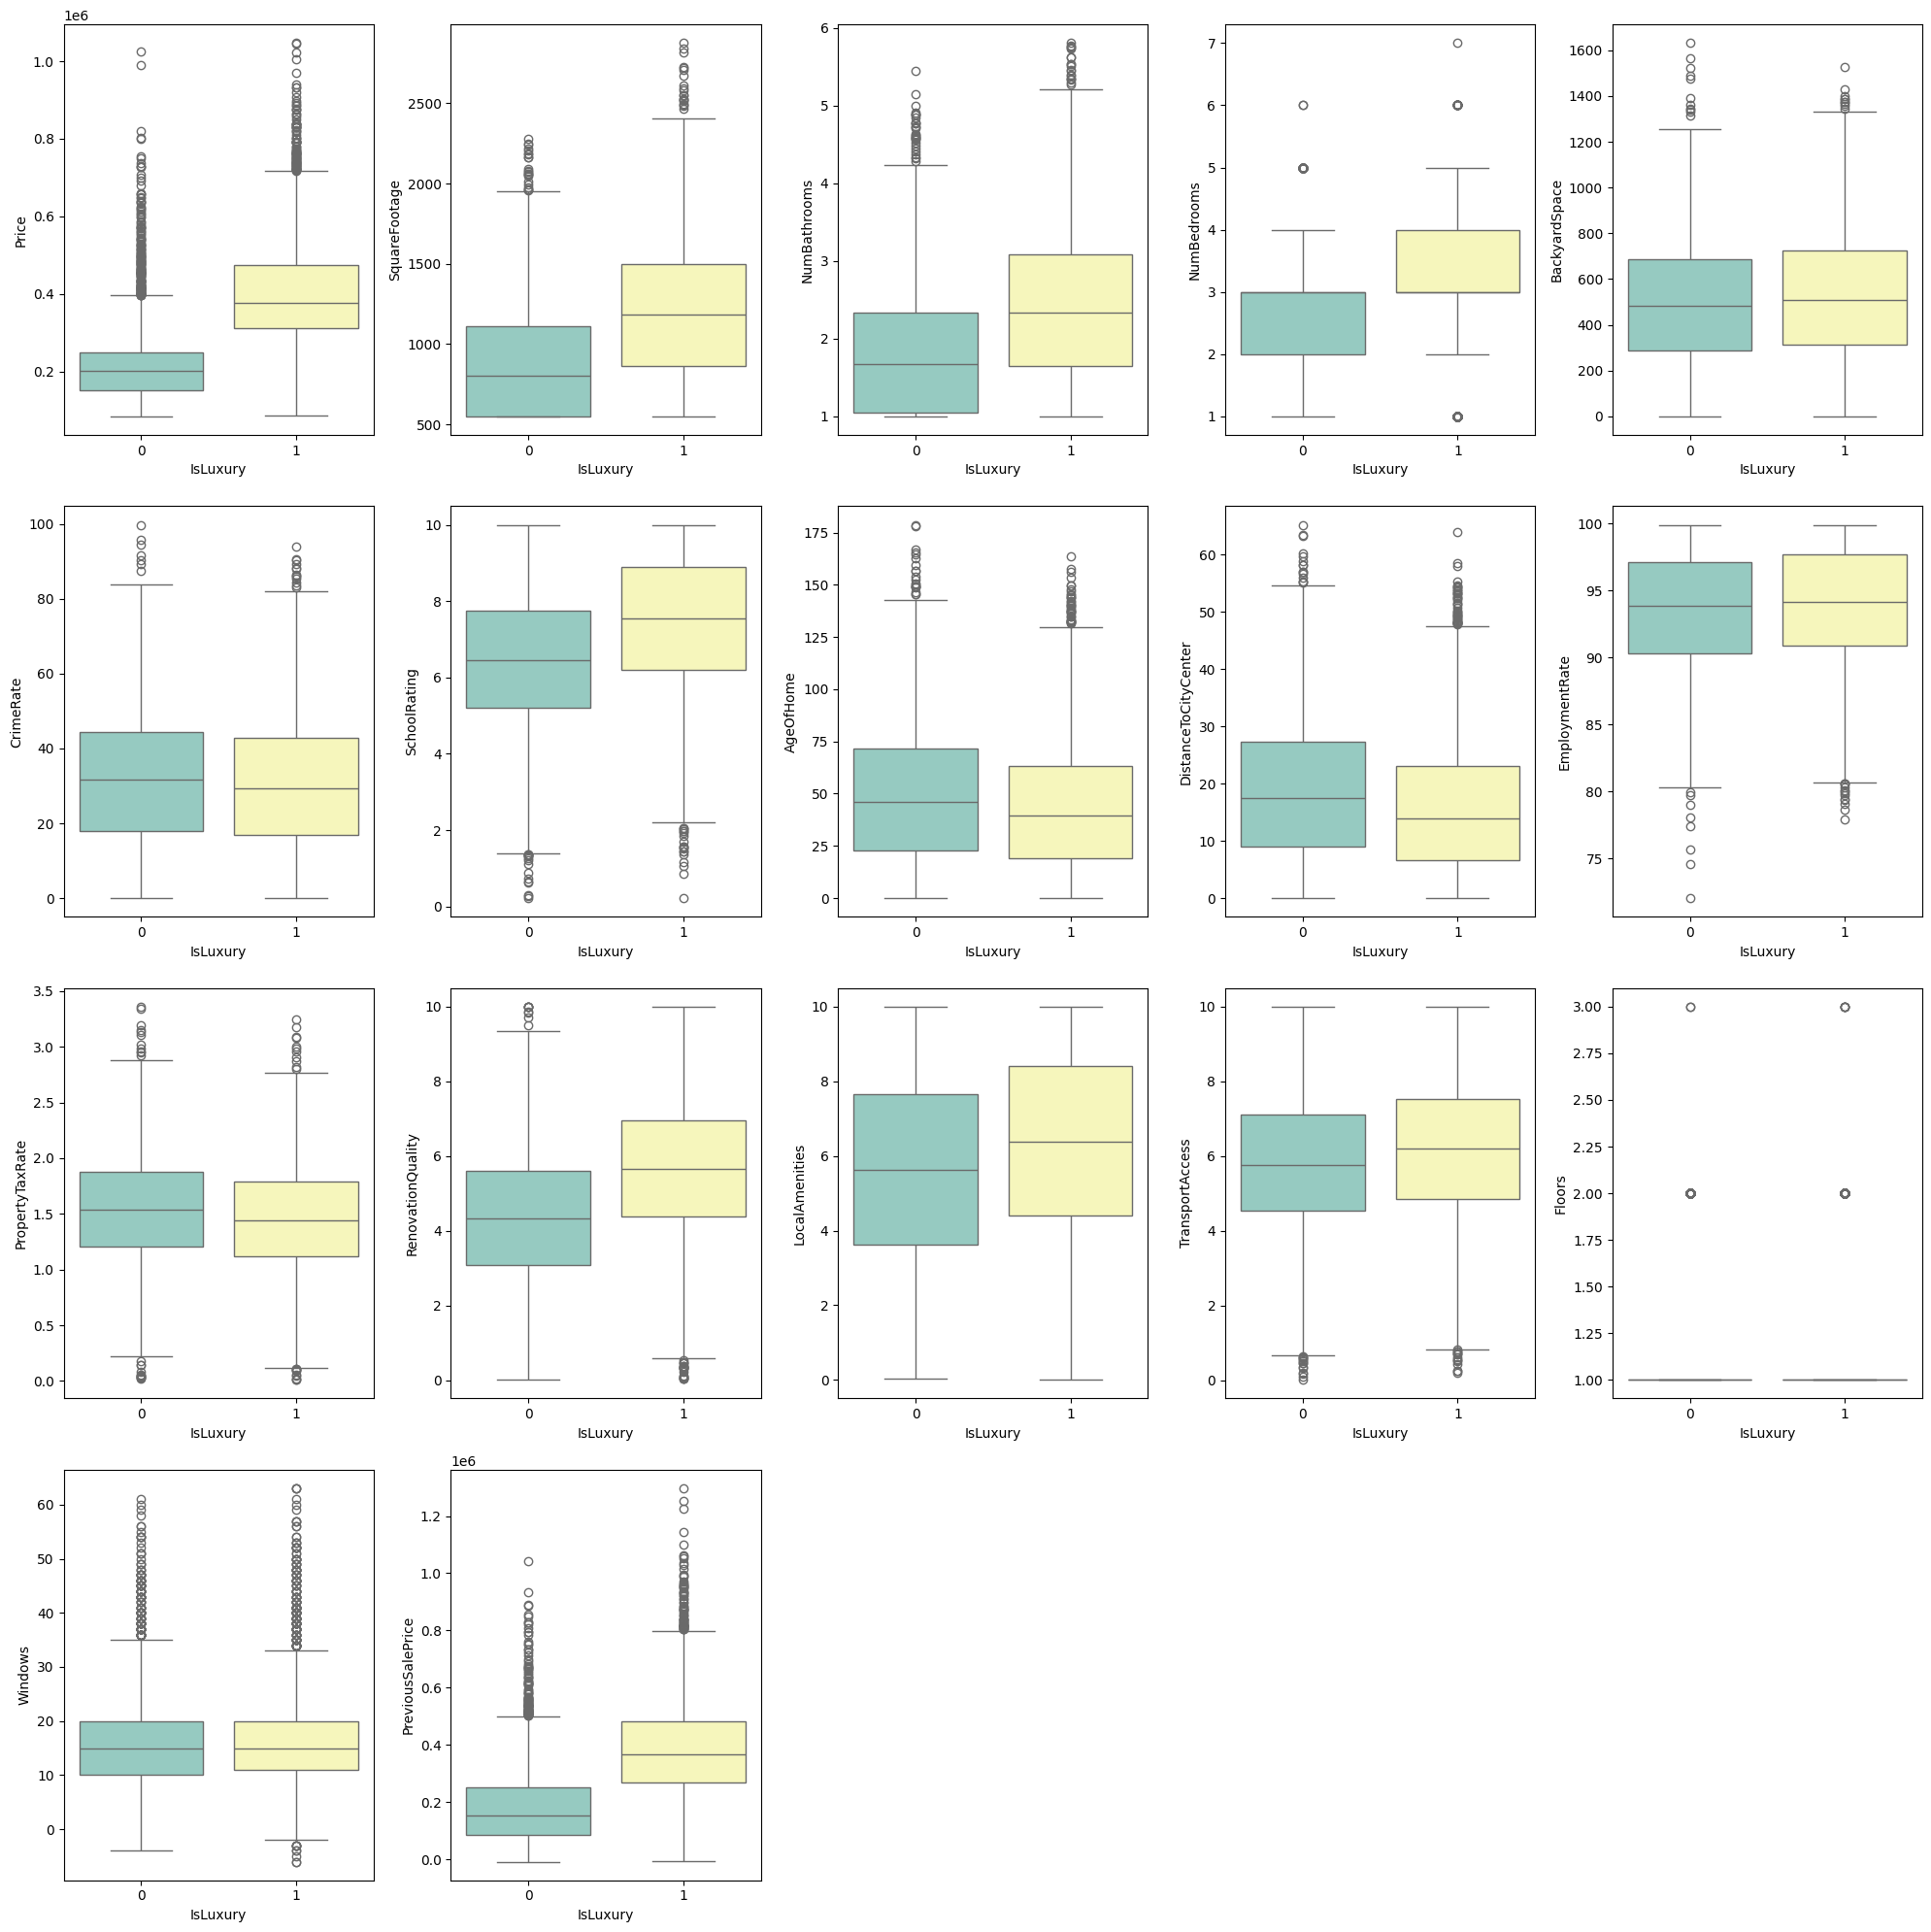

In [20]:
independent_vars = df_num.columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 20))
axes = axes.flatten()  

for i, var in enumerate(independent_vars):
    sns.boxplot(x='IsLuxury', y=var, data=df, ax=axes[i], palette='Set3')
    axes[i].set_xlabel('IsLuxury')
    axes[i].set_ylabel(var)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


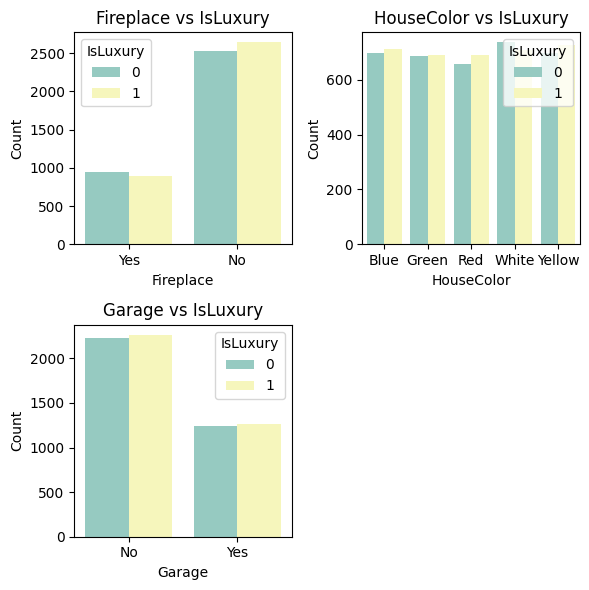

In [21]:
cat_cols = df_cat.columns.tolist()  
target = 'IsLuxury'

rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
axes = axes.flatten()  

for i, col in enumerate(cat_cols):
    if i < rows*cols: 
        sns.countplot(x=col, hue=target, data=df, palette='Set3', ax=axes[i])
        axes[i].set_title(f'{col} vs {target}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

# Hide empty subplots
for j in range(i+1, rows*cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Encode the Data

In [22]:
# encode the 2 columns
df = pd.get_dummies(df, columns=["Fireplace", "HouseColor", "Garage"], drop_first=True, prefix=["Fireplace", "HouseColor", "Garage"])
# Map values to 1 and 0
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,...,Floors,Windows,PreviousSalePrice,IsLuxury,Fireplace_Yes,HouseColor_Green,HouseColor_Red,HouseColor_White,HouseColor_Yellow,Garage_Yes
0,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,97.29,...,1,13,181861.54230,0,1,0,0,0,0,0
1,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,93.22,...,1,17,50042.59757,0,0,1,0,0,0,0
2,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,96.60,...,2,34,48400.34440,0,1,1,0,0,0,1
3,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,91.45,...,1,14,84594.12145,0,1,0,1,0,0,0
4,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,86.50,...,1,21,22934.59654,0,0,0,0,1,0,1


# Split the Dataset

In [23]:
y= df['IsLuxury']
X=df.drop(columns = ['IsLuxury'])

# split the data into 80/20
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=1, 
                                   test_size=0.20)

In [24]:
print(X_train.shape)
X_train.to_csv("X_train.csv")

print(X_test.shape)
X_test.to_csv("X_test.csv")

print(y_train.shape)
y_train.to_csv("y_train.csv")

print(y_test.shape)
y_test.to_csv("y_test.csv")

(5600, 23)
(1400, 23)
(5600,)
(1400,)


# Train the Model (Before Optimization)

In [25]:
# Logic adapted from GeeksforGeeks (2025)
# Source: https://www.geeksforgeeks.org/machine-learning/logistic-regression-using-statsmodels/

X_train = sm.add_constant(X_train)

logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.420567
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               IsLuxury   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5576
Method:                           MLE   Df Model:                           23
Date:                Sun, 26 Oct 2025   Pseudo R-squ.:                  0.3932
Time:                        17:51:00   Log-Likelihood:                -2355.2
converged:                       True   LL-Null:                       -3881.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.6516      0.843     -6.706      0.000      -7.303      -4.000

In [26]:
print("AIC:", result.aic)
print("BIC:", result.bic)

AIC: 4758.350766152567
BIC: 4917.483291193925


### Training Set Metrics

In [27]:
y_pred = result.predict(X_train)
y_pred = (y_pred > 0.5).astype(int)

In [28]:
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[2522  268]
 [ 400 2410]]


In [29]:
acc = accuracy_score(y_train, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8807142857142857


### Testing set Metrics

In [30]:
X_test = sm.add_constant(X_test)

y_pred = result.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)



In [31]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[615  67]
 [116 602]]


In [32]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8692857142857143


# Check for Independence for Residuals

In [33]:
# Calculate residuals
residuals = result.resid_pearson  # deviance residuals for logistic regression

# Durbin-Watson statistic
dw_stat = durbin_watson(residuals)
print("Durbin-Watson statistic:", dw_stat)

Durbin-Watson statistic: 2.005213648034615


# Check for Multicollinearity

In [34]:
# Add constant for intercept
# X_sm = sm.add_constant(X_train)
X_sm = X_train

# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_sm.columns
vif_data['VIF'] = [variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])]

print(vif_data)

                 Feature         VIF
0                  const  525.059120
1                  Price    3.349284
2          SquareFootage    1.981532
3           NumBathrooms    1.584653
4            NumBedrooms    1.797187
5          BackyardSpace    1.025847
6              CrimeRate    1.053705
7           SchoolRating    1.582992
8              AgeOfHome    1.047755
9   DistanceToCityCenter    1.088409
10        EmploymentRate    1.070199
11       PropertyTaxRate    1.057783
12     RenovationQuality    1.689800
13        LocalAmenities    1.346309
14       TransportAccess    1.346898
15                Floors    1.540312
16               Windows    1.538298
17     PreviousSalePrice    4.360111
18         Fireplace_Yes    1.004982
19      HouseColor_Green    1.612782
20        HouseColor_Red    1.602754
21      HouseColor_White    1.631449
22     HouseColor_Yellow    1.615052
23            Garage_Yes    1.002298


# Backward Stepwise Elimination

In [35]:
# Logic adapted from GeeksforGeeks (2025h)
# Source: https://www.geeksforgeeks.org/machine-learning/stepwise-regression-in-python/

# Add constant for intercept
X = X_train

# Set significance level
SL = 0.05

# Initialize list of columns
cols = list(X.columns)

while True:
    model = sm.Logit(y_train, X[cols]).fit(disp=False)
    pvalues = model.pvalues.iloc[1:]  # exclude constant
    max_pval = pvalues.max()
    if max_pval > SL:
        # Remove the variable with the highest p-value
        excluded = pvalues.idxmax()
        cols.remove(excluded)
        print(f"Removed {excluded} with p-value {max_pval:.4f}")
    else:
        break

Removed EmploymentRate with p-value 0.9332
Removed HouseColor_Red with p-value 0.8923
Removed Garage_Yes with p-value 0.8255
Removed TransportAccess with p-value 0.7874
Removed Floors with p-value 0.7448
Removed Fireplace_Yes with p-value 0.7063
Removed BackyardSpace with p-value 0.7033
Removed CrimeRate with p-value 0.6190
Removed SchoolRating with p-value 0.6405
Removed NumBathrooms with p-value 0.5365
Removed HouseColor_White with p-value 0.5266
Removed HouseColor_Green with p-value 0.6538
Removed HouseColor_Yellow with p-value 0.6970
Removed LocalAmenities with p-value 0.4878
Removed AgeOfHome with p-value 0.4219
Removed RenovationQuality with p-value 0.3948
Removed NumBedrooms with p-value 0.2968
Removed SquareFootage with p-value 0.3987
Removed PropertyTaxRate with p-value 0.1252
Removed PreviousSalePrice with p-value 0.0701
Removed DistanceToCityCenter with p-value 0.0561


In [36]:
logit_model = sm.Logit(y_train, X[cols])
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.421915
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               IsLuxury   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5597
Method:                           MLE   Df Model:                            2
Date:                Sun, 26 Oct 2025   Pseudo R-squ.:                  0.3913
Time:                        17:51:01   Log-Likelihood:                -2362.7
converged:                       True   LL-Null:                       -3881.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.8520      0.143    -33.856      0.000      -5.133      -4.571
Price       1.627e-05   4.33e

In [37]:
print("AIC:", result.aic)
print("BIC:", result.bic)

AIC: 4731.443190210072
BIC: 4751.334755840242


Large Sample Size

In [38]:
X_train[cols].info()
X_test[cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 5600 entries, 4815 to 5157
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   const    5600 non-null   float64
 1   Price    5600 non-null   float64
 2   Windows  5600 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 175.0 KB
<class 'pandas.core.frame.DataFrame'>
Index: 1400 entries, 2305 to 5823
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   const    1400 non-null   float64
 1   Price    1400 non-null   float64
 2   Windows  1400 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 43.8 KB


Check for Multicollinearity

In [39]:
# Add constant for intercept
# X_sm = sm.add_constant(X_train)
X_sm = X[cols]

# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_sm.columns
vif_data['VIF'] = [variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])]

print(vif_data)

   Feature       VIF
0    const  8.324779
1    Price  1.000319
2  Windows  1.000319


Duplicates

In [40]:
X_sm.duplicated().sum()

np.int64(0)

### Training Set Metrics

In [41]:
y_pred = result.predict(X_train[cols])
y_pred = (y_pred > 0.5).astype(int)

In [42]:
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[2537  253]
 [ 418 2392]]


In [43]:
acc = accuracy_score(y_train, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8801785714285715


In [44]:
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print("Precision: ", precision)
print("Recall: " , recall)
print("F1 Score: " , f1)

Precision:  0.9043478260869565
Recall:  0.8512455516014235
F1 Score:  0.876993583868011


### Testing set Metrics

In [45]:
X_test = sm.add_constant(X_test[cols])

y_pred = result.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)


In [46]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[619  63]
 [110 608]]


In [47]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8764285714285714


In [48]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision: ", precision)
print("Recall: " , recall)
print("F1 Score: " , f1)

Precision:  0.9061102831594635
Recall:  0.8467966573816156
F1 Score:  0.8754499640028798
